# 05 - Ablation: Learned g(k) vs. Fixed 1/k

**Summary.** The ablation isolates the *learning* of the distance curve:
DDM (learned gate) vs. DDM-Ablation (gate frozen to $1/k$), everything else
identical. We train both across multiple seeds, report mean ± std, overlay
the learned g(k) curves per seed, and run a simple two-sample t-test
(implemented with numpy only). Set `DDM_SMOKE=1` for a quick smoke run.

In [ ]:
# --- Colab / Kaggle setup: clone the DDM repo and expose the package ---
import os, subprocess, sys
from pathlib import Path

REPO_URL = "https://github.com/yaso09/ddm.git"

def _find_repo_root() -> Path | None:
    here = Path.cwd()
    for cand in [here, here.parent, here.parent.parent]:
        if (cand / "configs").is_dir() and (cand / "src" / "ddm").is_dir():
            return cand
    return None

ROOT = _find_repo_root()
if ROOT is None:
    # Fresh cloud environment (Colab/Kaggle): clone the repository.
    print("[setup] cloning DDM repository ...")
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, "ddm"], check=True)
    ROOT = Path.cwd() / "ddm"

os.chdir(ROOT)
# The package lives under src/; add it so `import ddm` works.
sys.path.insert(0, str(ROOT / "src"))
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("repo root:", ROOT)


In [1]:
# --- repo root bootstrap: lets the notebook run from any working directory ---
import os, sys
from pathlib import Path

def _find_root() -> Path:
    here = Path.cwd()
    for cand in [here, here.parent, here.parent.parent]:
        if (cand / "configs").is_dir() and (cand / "src" / "ddm").is_dir():
            return cand
    return here

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)
SMOKE = os.environ.get("DDM_SMOKE", "0") == "1"
print("repo root:", ROOT, "| DDM_SMOKE:", SMOKE)


repo root: C:\Users\yasir\Desktop\ammar | DDM_SMOKE: True


In [2]:
import math
from pathlib import Path

from ddm.config import DDMConfig
from ddm.train import run_training
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [3]:
def t_pdf(x: float, df: float) -> float:
    """Student-t density, via math.lgamma (no scipy needed)."""
    return math.exp(math.lgamma((df + 1) / 2) - math.lgamma(df / 2)) * (
        1 + x * x / df
    ) ** (-(df + 1) / 2) / math.sqrt(df * math.pi)


def welch_ttest(a, b):
    """Two-sample Welch t-test -> (t, df, two-sided p-value)."""
    a, b = np.asarray(a, float), np.asarray(b, float)
    na, nb = a.size, b.size
    ma, mb = a.mean(), b.mean()
    va, vb = a.var(ddof=1), b.var(ddof=1)
    se = math.sqrt(va / na + vb / nb)
    t = (ma - mb) / se
    df = (va / na + vb / nb) ** 2 / ((va / na) ** 2 / (na - 1) + (vb / nb) ** 2 / (nb - 1))
    xs = np.linspace(abs(t), 80.0, 400_000)
    p = 2.0 * np.trapezoid([t_pdf(x, df) for x in xs], xs)
    return t, df, p

In [4]:
seeds = [0, 1, 2] if not SMOKE else [0, 1]
cfg_ddm = DDMConfig.from_yaml("configs/ddm_base.yaml")
cfg_abl = DDMConfig.from_yaml("configs/ddm_ablation.yaml")
for cfg in (cfg_ddm, cfg_abl):
    cfg.seeds = seeds
    if SMOKE:
        cfg.max_steps = 3
        cfg.max_blocks = 64
        cfg.epochs = 1

In [5]:
res_ddm = run_training(cfg_ddm)
print()
res_abl = run_training(cfg_abl)

[train] device: cuda
[data] loading wikitext/wikitext-2-raw-v1 (cache: hf_cache)...


[data] script-based loading failed (HfUriError: Invalid HF URI 'hf://datasets/wikitext@b08601e04326c79dfdd32d625aee71d232d685c3/.huggingface.yaml'. Repository id must be 'namespace/name', got 'wikitext'.); switching to local parquet fallback...


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2391884 > 1024). Running this sequence through the model will result in indexing errors


[data] blocks -> train: (64, 128), val: (64, 128), test: (64, 128)
[train] vocab_size: 50257

=== seed 0 ===


[train] ddm parameters: 13,312,947


...

[train] epoch 1: loss 11.0094, val PPL 57450.60


[train] test PPL: 56821.40 (2.0s)



=== seed 1 ===
[train] ddm_ablation parameters: 13,312,849
--- epoch 1/1 ---


[train] epoch 1: loss 11.0055, val PPL 56528.33


[train] test PPL: 56247.01 (2.5s)


### Mean ± std over seeds

In [6]:
p_ddm = [e["test_ppl"] for e in res_ddm["per_seed"]]
p_abl = [e["test_ppl"] for e in res_abl["per_seed"]]
print(f"DDM          : {np.mean(p_ddm):.2f} ± {np.std(p_ddm):.2f}  (seeds {p_ddm})")
print(f"DDM-Ablation : {np.mean(p_abl):.2f} ± {np.std(p_abl):.2f}  (seeds {p_abl})")

t, df, p = welch_ttest(p_ddm, p_abl)
print(f"\nWelch t-test: t = {t:.3f}, df = {df:.1f}, p = {p:.4f}")
print("significant at alpha=0.05:", p < 0.05)

DDM          : 56536.99 ± 1432.16  (seeds [57969.15081522276, 55104.83099135828])
DDM-Ablation : 56534.21 ± 287.20  (seeds [56821.40378411846, 56247.01039159061])



Welch t-test: t = 0.002, df = 1.1, p = 0.9931
significant at alpha=0.05: False


### Learned g(k) curves per seed

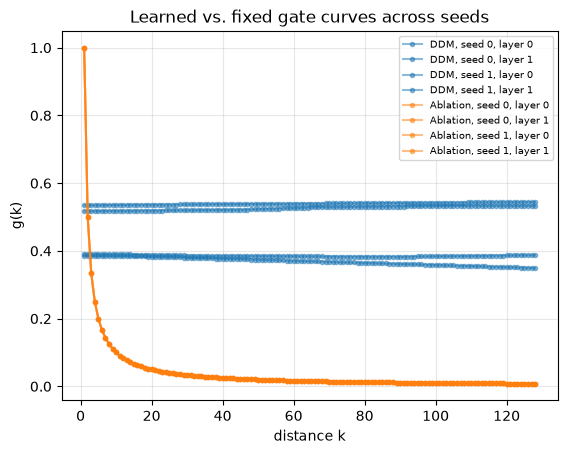

In [7]:
for res, color in ((res_ddm, "tab:blue"), (res_abl, "tab:orange")):
    for entry in res["per_seed"]:
        if entry["g_curve"] is None:
            continue
        data = np.load(entry["g_curve"].replace(".png", ".npz"))
        for layer in range(data["g"].shape[0]):
            plt.plot(data["k"], data["g"][layer], color=color, alpha=0.5,
                     marker="o", ms=3,
                     label=f"{'DDM' if color=='tab:blue' else 'Ablation'}, "
                           f"seed {entry['seed']}, layer {layer}")
plt.xlabel("distance k"); plt.ylabel("g(k)")
plt.title("Learned vs. fixed gate curves across seeds")
plt.grid(alpha=0.3); plt.legend(fontsize=7); plt.show()

### Interpretation

- If DDM's mean test PPL is below the ablation's and the t-test is
  significant, *learning* the distance curve adds real signal beyond the
  fixed $1/k$ decay.
- The g(k) plots show *how* the model uses distance: monotone decay means
  near context dominates; a rising tail or a hump at some distance means the
  model learned to boost long-range cues (e.g. sentence-level agreement).